In [1]:
# Upload required datasets in Google Colab

from google.colab import files

uploaded = files.upload()

Saving sales_data.csv to sales_data.csv
Saving customer_churn.csv to customer_churn.csv


In [2]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully ✅


In [3]:
# Load datasets

sales_df = pd.read_csv("sales_data.csv")
customer_df = pd.read_csv("customer_churn.csv")

print("Datasets loaded successfully")

sales_df.head()

Datasets loaded successfully


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
# Check dataset information

print("Sales Dataset Shape:", sales_df.shape)
print("\nCustomer Dataset Shape:", customer_df.shape)

print("\nSales Dataset Columns:")
print(sales_df.columns)

print("\nCustomer Dataset Columns:")
print(customer_df.columns)

print("\nMissing Values:")
print(sales_df.isnull().sum())

Sales Dataset Shape: (100, 7)

Customer Dataset Shape: (500, 9)

Sales Dataset Columns:
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

Customer Dataset Columns:
Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [5]:
# Calculate descriptive statistics

mean_sales = sales_df["Total_Sales"].mean()
median_sales = sales_df["Total_Sales"].median()
mode_sales = sales_df["Total_Sales"].mode()[0]
std_sales = sales_df["Total_Sales"].std()

print("DESCRIPTIVE STATISTICS")
print("=" * 40)

print(f"Mean Sales: {mean_sales:.2f}")
print(f"Median Sales: {median_sales:.2f}")
print(f"Mode Sales: {mode_sales:.2f}")
print(f"Standard Deviation: {std_sales:.2f}")

DESCRIPTIVE STATISTICS
Mean Sales: 123650.48
Median Sales: 97955.50
Mode Sales: 6540.00
Standard Deviation: 100161.09


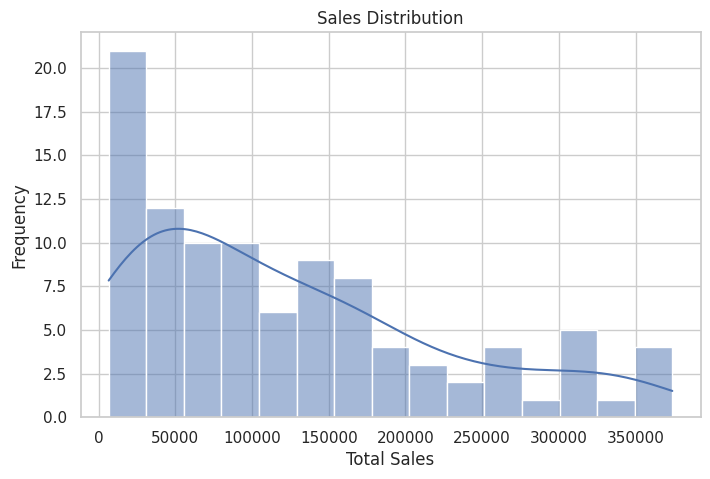

In [6]:
# Create histogram and density plot

plt.figure(figsize=(8,5))

sns.histplot(
    sales_df["Total_Sales"],
    kde=True,
    bins=15
)

plt.title("Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

In [7]:
# Correlation matrix

correlation_matrix = sales_df[
    ["Quantity", "Price", "Total_Sales"]
].corr()

print(correlation_matrix)

             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


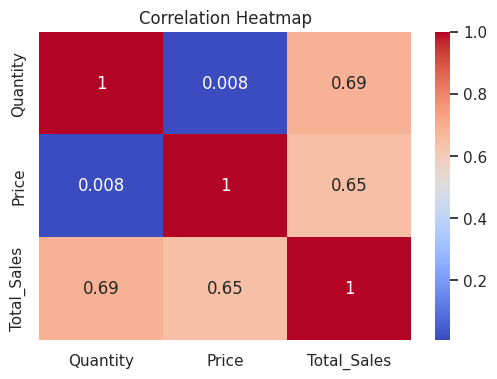

In [8]:
# Create heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
# Hypothesis Test 1
# Compare sales between North and South regions

north_sales = sales_df[
    sales_df["Region"] == "North"
]["Total_Sales"]

south_sales = sales_df[
    sales_df["Region"] == "South"
]["Total_Sales"]

t_stat, p_value = ttest_ind(
    north_sales,
    south_sales
)

print("T-TEST RESULTS")
print("=" * 40)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Significant Difference")
else:
    print("Result: No Significant Difference")

T-TEST RESULTS
T-statistic: 0.1303316283399723
P-value: 0.8967974805172008
Result: No Significant Difference


In [11]:
# ANOVA test across regions

north = sales_df[sales_df["Region"] == "North"]["Total_Sales"]
south = sales_df[sales_df["Region"] == "South"]["Total_Sales"]
east = sales_df[sales_df["Region"] == "East"]["Total_Sales"]
west = sales_df[sales_df["Region"] == "West"]["Total_Sales"]

anova_result = f_oneway(
    north,
    south,
    east,
    west
)

print("ANOVA TEST")
print("=" * 40)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

ANOVA TEST
F-statistic: 2.164363429897842
P-value: 0.09723678084980039


In [12]:
# Compare Laptop and Phone sales

laptop_sales = sales_df[
    sales_df["Product"] == "Laptop"
]["Total_Sales"]

phone_sales = sales_df[
    sales_df["Product"] == "Phone"
]["Total_Sales"]

t_stat2, p_value2 = ttest_ind(
    laptop_sales,
    phone_sales
)

print("PRODUCT SALES T-TEST")
print("=" * 40)

print("T-statistic:", t_stat2)
print("P-value:", p_value2)

PRODUCT SALES T-TEST
T-statistic: 0.5605688172629398
P-value: 0.5780698288487449


In [13]:
# Calculate 95% confidence interval

confidence_level = 0.95

mean = sales_df["Total_Sales"].mean()
std_error = stats.sem(sales_df["Total_Sales"])

confidence_interval = stats.t.interval(
    confidence_level,
    len(sales_df["Total_Sales"]) - 1,
    loc=mean,
    scale=std_error
)

print("95% CONFIDENCE INTERVAL")
print("=" * 40)

print(confidence_interval)

95% CONFIDENCE INTERVAL
(np.float64(103776.34767158539), np.float64(143524.6123284146))


In [14]:
# Linear Regression Analysis

X = sales_df[["Price"]]
y = sales_df["Total_Sales"]

model = LinearRegression()

model.fit(X, y)

predictions = model.predict(X)

r2 = r2_score(y, predictions)

print("REGRESSION ANALYSIS")
print("=" * 40)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R-squared:", r2)

REGRESSION ANALYSIS
Intercept: 3640.5434732834547
Coefficient: 4.650014143657133
R-squared: 0.41748520826938107


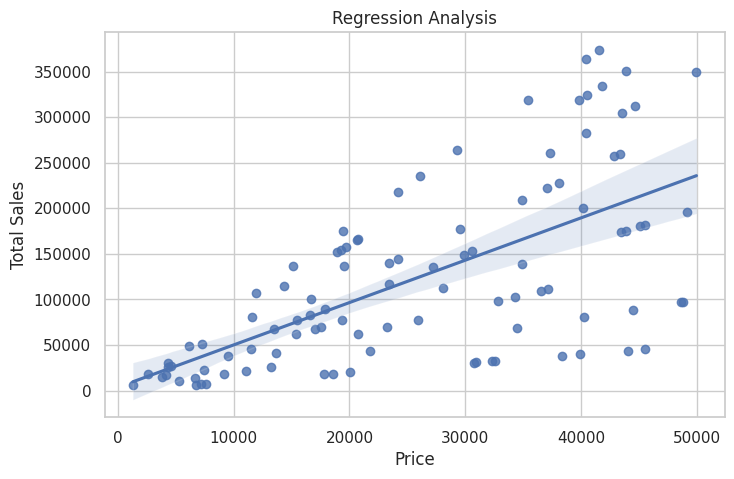

In [15]:
# Regression visualization

plt.figure(figsize=(8,5))

sns.regplot(
    x="Price",
    y="Total_Sales",
    data=sales_df
)

plt.title("Regression Analysis")
plt.xlabel("Price")
plt.ylabel("Total Sales")

plt.show()

In [16]:
# Final business report

print("=" * 60)
print("STATISTICAL BUSINESS ANALYSIS REPORT")
print("=" * 60)

print(f"Average Sales: {mean_sales:.2f}")
print(f"Median Sales: {median_sales:.2f}")
print(f"Standard Deviation: {std_sales:.2f}")

print("\nCorrelation Analysis:")
print(correlation_matrix)

print("\nConfidence Interval:")
print(confidence_interval)

print("\nRegression R-Squared:")
print(r2)

print("=" * 60)

STATISTICAL BUSINESS ANALYSIS REPORT
Average Sales: 123650.48
Median Sales: 97955.50
Standard Deviation: 100161.09

Correlation Analysis:
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000

Confidence Interval:
(np.float64(103776.34767158539), np.float64(143524.6123284146))

Regression R-Squared:
0.41748520826938107
